In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('leaderboard_data_overall.csv', header=None,
                 names=['position','delta_position','uid','name','country_code','score'])
df.head()

,position,delta_position,uid,name,country_code,score
0,1,NaN,0aefbe81-3fab-49fa-af59-d86bdb34c5e1,yuh,AU,213845.27
1,2,NaN,97cb0d22-3873-4057-a856-28edf35c3387,Negative Eevee,NL,211239.51
2,3,NaN,60044fb4-0584-4d19-ba15-6f43d8e6f36a,Vibing,AU,209840.98
3,4,NaN,b2342095-b087-4597-9da1-564208152129,Seven Deuce Capital,US,208281.23
4,5,NaN,98265c6c-2e7e-414c-b8e3-806564f475f3,DU Trading,GB,208205.91


In [14]:
# Basic stats - full leaderboard
print(f"Total entries: {len(df)}")
print(f"Countries: {df['country_code'].nunique()}")
print()
print(df['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
p95 = df['score'].quantile(0.95)
p99 = df['score'].quantile(0.99)
print(f"95th percentile: {p95:,.2f}")
print(f"99th percentile: {p99:,.2f}")
print(f"Top score: {df['score'].max():,.2f}")
print(f"Bottom score: {df['score'].min():,.2f}")

Total entries: 22130
Countries: 132

count    2.213000e+04
mean     2.711970e+04
std      3.102893e+05
min     -4.037506e+07
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.297174e+04
90%      1.674800e+05
95%      1.838536e+05
99%      1.898930e+05
max      2.138453e+05
Name: score, dtype: float64

95th percentile: 183,853.64
99th percentile: 189,892.96
Top score: 213,845.27
Bottom score: -40,375,062.55


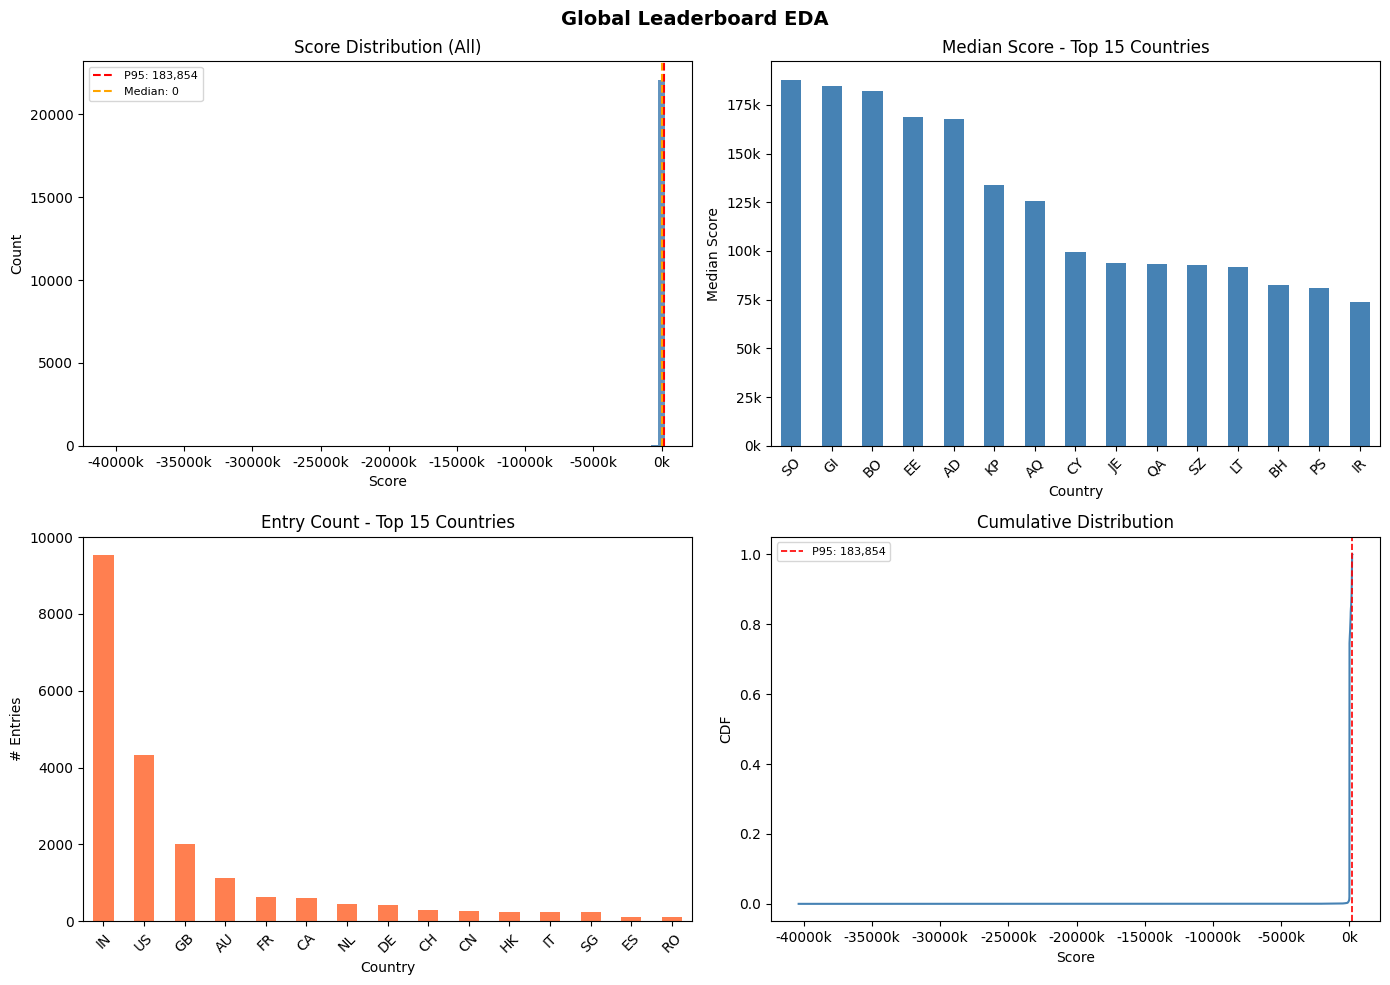

In [15]:
# --- GLOBAL EDA ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Global Leaderboard EDA', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(df['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(p95, color='red', linestyle='--', linewidth=1.5, label=f'P95: {p95:,.0f}')
ax.axvline(df['score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (All)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

top_countries = df.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[0, 1]
top_countries.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Countries')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

top_count = df['country_code'].value_counts().head(15)
ax = axes[1, 0]
top_count.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('# Entries'); ax.set_title('Entry Count - Top 15 Countries')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
sorted_scores = np.sort(df['score'])
cdf = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
ax.plot(sorted_scores, cdf, color='steelblue', linewidth=1.5)
ax.axvline(p95, color='red', linestyle='--', linewidth=1.2, label=f'P95: {p95:,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Distribution')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('leaderboard_global_eda.png', dpi=130, bbox_inches='tight')
plt.show()

In [16]:
# --- INDIA (IN) FILTERED EDA ---
df_in = df[df['country_code'] == 'IN'].copy()
print(f"India entries: {len(df_in)}")
print(f"India rank range: {df_in['position'].min()} - {df_in['position'].max()}")
print()
p95_in = df_in['score'].quantile(0.95)
p99_in = df_in['score'].quantile(0.99)
print(df_in['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (IN): {p95_in:,.2f}")
print(f"99th percentile (IN): {p99_in:,.2f}")
print(f"Top India score: {df_in['score'].max():,.2f}  (global rank #{df_in.loc[df_in['score'].idxmax(),'position']})")

India entries: 9531
India rank range: 23 - 5892

count    9.531000e+03
mean     1.383053e+04
std      2.011148e+05
min     -1.784918e+07
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      9.025744e+04
95%      1.649089e+05
99%      1.869014e+05
max      2.046790e+05
Name: score, dtype: float64

95th percentile (IN): 164,908.94
99th percentile (IN): 186,901.42
Top India score: 204,679.04  (global rank #23)


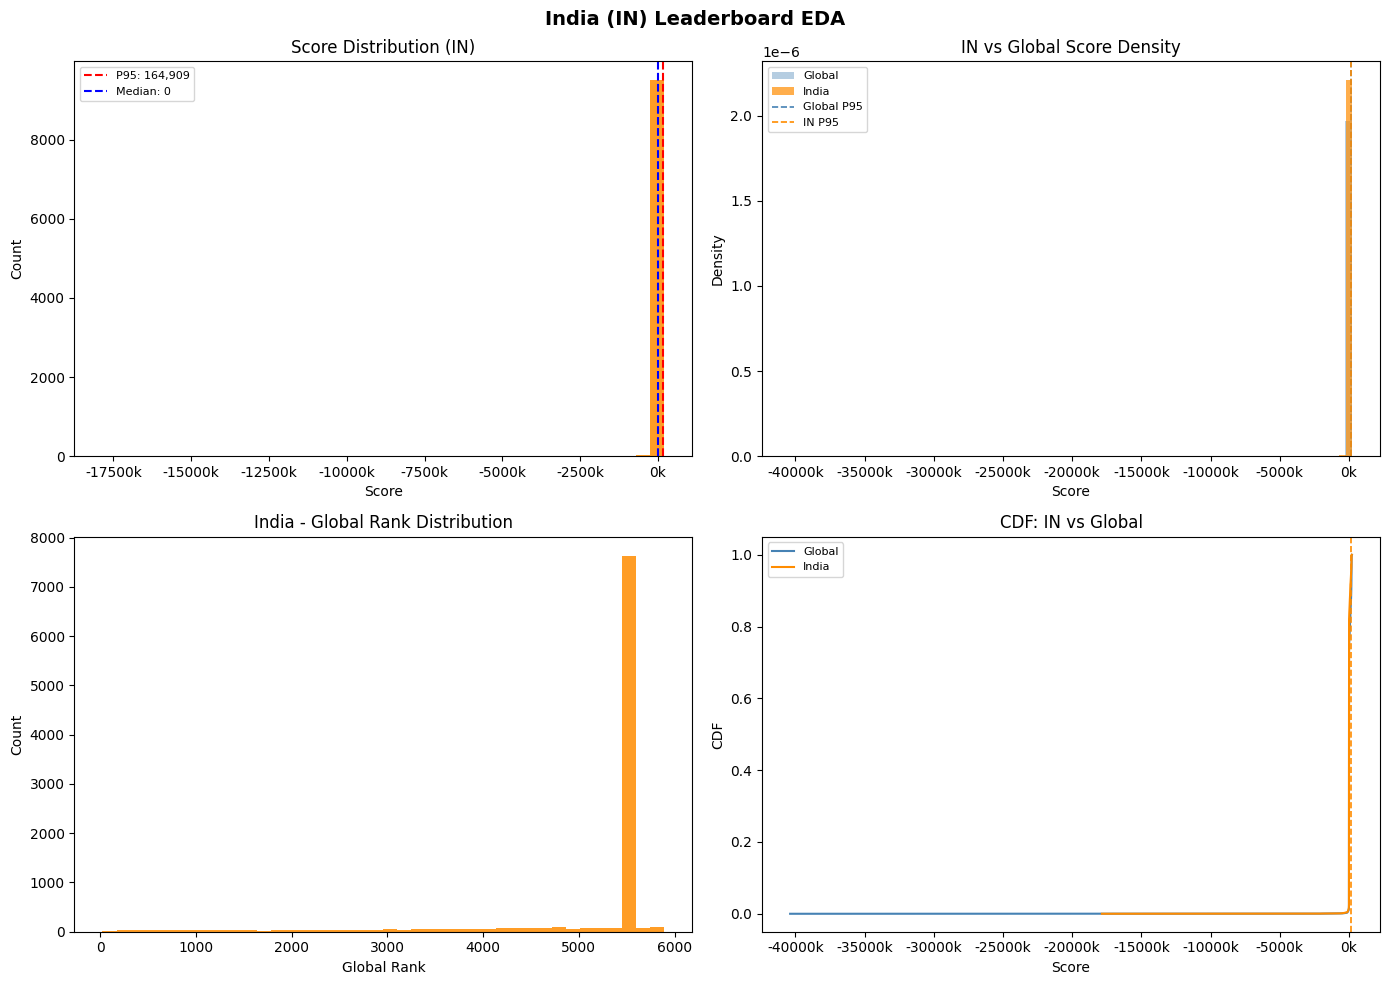

In [17]:
# --- INDIA PLOTS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('India (IN) Leaderboard EDA', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(df_in['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.axvline(p95_in, color='red', linestyle='--', linewidth=1.5, label=f'P95: {p95_in:,.0f}')
ax.axvline(df_in['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {df_in["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (IN)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(df['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(df_in['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.7, density=True, label='India')
ax.axvline(p95, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(p95_in, color='darkorange', linestyle='--', linewidth=1.2, label='IN P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('IN vs Global Score Density')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(df_in['position'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.set_xlabel('Global Rank'); ax.set_ylabel('Count'); ax.set_title('India - Global Rank Distribution')

ax = axes[1, 1]
sorted_global = np.sort(df['score'])
cdf_global = np.arange(1, len(sorted_global)+1) / len(sorted_global)
sorted_in = np.sort(df_in['score'])
cdf_in = np.arange(1, len(sorted_in)+1) / len(sorted_in)
ax.plot(sorted_global, cdf_global, color='steelblue', linewidth=1.5, label='Global')
ax.plot(sorted_in, cdf_in, color='darkorange', linewidth=1.5, label='India')
ax.axvline(p95_in, color='darkorange', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: IN vs Global')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('leaderboard_india_eda.png', dpi=130, bbox_inches='tight')
plt.show()

In [18]:

# --- FILTER score > 0 ---
df_pos = df[df['score'] > 0].copy()
df_in_pos = df_pos[df_pos['country_code'] == 'IN'].copy()

print(f"Global: {len(df)} → {len(df_pos)} (dropped {len(df)-len(df_pos)} zero/negative)")
print(f"India:  {len(df_in)} → {len(df_in_pos)} (dropped {len(df_in)-len(df_in_pos)})")


Global: 22130 → 5782 (dropped 16348 zero/negative)
India:  9531 → 1791 (dropped 7740)


In [19]:

# --- GLOBAL STATS (score > 0) ---
print(f"Total entries: {len(df_pos)}")
print(f"Countries: {df_pos['country_code'].nunique()}")
print()
print(df_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
p95_pos = df_pos['score'].quantile(0.95)
p99_pos = df_pos['score'].quantile(0.99)
print(f"95th percentile: {p95_pos:,.2f}")
print(f"99th percentile: {p99_pos:,.2f}")
print(f"Top score: {df_pos['score'].max():,.2f}")
print(f"Bottom score: {df_pos['score'].min():,.2f}")


Total entries: 5782
Countries: 89

count      5782.000000
mean     124458.395870
std       60299.976856
min           4.000000
5%        14676.184000
25%       76381.355000
50%      143117.005000
75%      181705.670000
90%      186860.176000
95%      188776.931000
99%      197935.475900
max      213845.270000
Name: score, dtype: float64

95th percentile: 188,776.93
99th percentile: 197,935.48
Top score: 213,845.27
Bottom score: 4.00


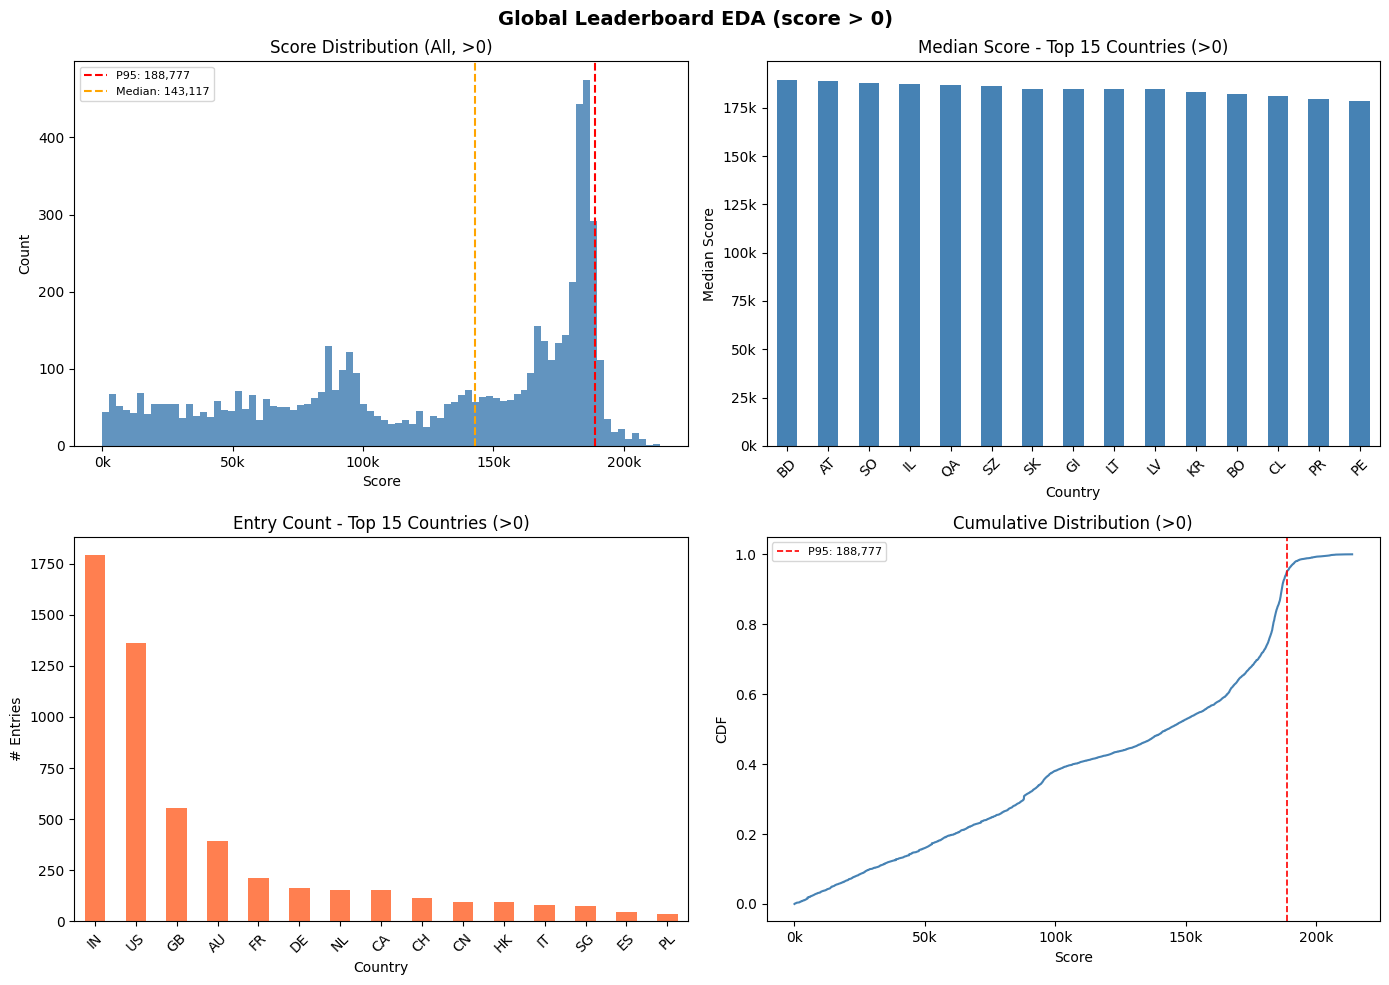

In [20]:

# --- GLOBAL EDA (score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Global Leaderboard EDA (score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(df_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(p95_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {p95_pos:,.0f}')
ax.axvline(df_pos['score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (All, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

top_countries_pos = df_pos.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[0, 1]
top_countries_pos.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Countries (>0)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

top_count_pos = df_pos['country_code'].value_counts().head(15)
ax = axes[1, 0]
top_count_pos.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('# Entries'); ax.set_title('Entry Count - Top 15 Countries (>0)')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
sorted_pos = np.sort(df_pos['score'])
cdf_pos = np.arange(1, len(sorted_pos)+1) / len(sorted_pos)
ax.plot(sorted_pos, cdf_pos, color='steelblue', linewidth=1.5)
ax.axvline(p95_pos, color='red', linestyle='--', linewidth=1.2, label=f'P95: {p95_pos:,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Distribution (>0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('leaderboard_global_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()


In [21]:

# --- INDIA STATS (score > 0) ---
print(f"India entries: {len(df_in_pos)}")
print(f"India rank range: {df_in_pos['position'].min()} - {df_in_pos['position'].max()}")
print()
p95_in_pos = df_in_pos['score'].quantile(0.95)
p99_in_pos = df_in_pos['score'].quantile(0.99)
print(df_in_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (IN, >0): {p95_in_pos:,.2f}")
print(f"99th percentile (IN, >0): {p99_in_pos:,.2f}")
print(f"Top India score: {df_in_pos['score'].max():,.2f}  (global rank #{df_in_pos.loc[df_in_pos['score'].idxmax(),'position']})")


India entries: 1791
India rank range: 23 - 5537

count      1791.000000
mean     102133.874662
std       61769.287017
min          13.800000
5%         8528.295000
25%       48883.205000
50%       94189.470000
75%      166798.595000
90%      184282.540000
95%      187137.490000
99%      191540.196000
max      204679.040000
Name: score, dtype: float64

95th percentile (IN, >0): 187,137.49
99th percentile (IN, >0): 191,540.20
Top India score: 204,679.04  (global rank #23)


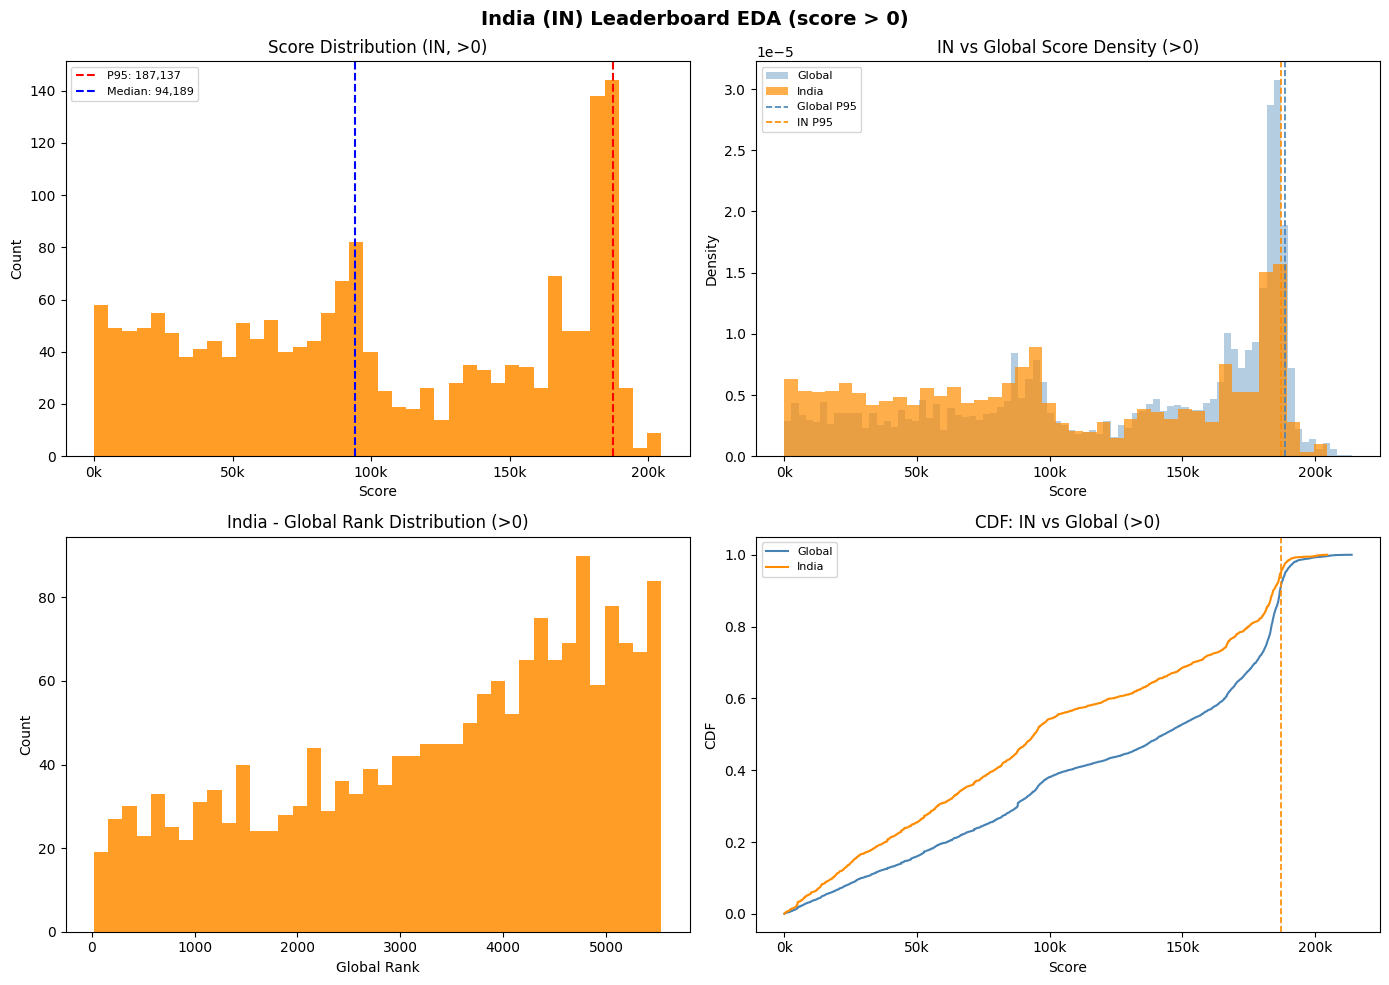

In [22]:

# --- INDIA PLOTS (score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('India (IN) Leaderboard EDA (score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(df_in_pos['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.axvline(p95_in_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {p95_in_pos:,.0f}')
ax.axvline(df_in_pos['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {df_in_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (IN, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(df_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(df_in_pos['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.7, density=True, label='India')
ax.axvline(p95_pos, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(p95_in_pos, color='darkorange', linestyle='--', linewidth=1.2, label='IN P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('IN vs Global Score Density (>0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(df_in_pos['position'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.set_xlabel('Global Rank'); ax.set_ylabel('Count'); ax.set_title('India - Global Rank Distribution (>0)')

ax = axes[1, 1]
sorted_global_pos = np.sort(df_pos['score'])
cdf_global_pos = np.arange(1, len(sorted_global_pos)+1) / len(sorted_global_pos)
sorted_in_pos = np.sort(df_in_pos['score'])
cdf_in_pos = np.arange(1, len(sorted_in_pos)+1) / len(sorted_in_pos)
ax.plot(sorted_global_pos, cdf_global_pos, color='steelblue', linewidth=1.5, label='Global')
ax.plot(sorted_in_pos, cdf_in_pos, color='darkorange', linewidth=1.5, label='India')
ax.axvline(p95_in_pos, color='darkorange', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: IN vs Global (>0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('leaderboard_india_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()


---
## leaderboard_data_manual.csv — Full Analysis

In [23]:

# Load manual CSV
dm = pd.read_csv('leaderboard_data_manual.csv', header=None,
                 names=['position','delta_position','uid','name','country_code','score'])
dm.head()


,position,delta_position,uid,name,country_code,score
0,1,NaN,2e32fbbc-e9f0-44e2-8ac7-d1391d1b086f,Kawiarnia Szkocka,PL,87995.1
1,1,NaN,cd91410a-eb42-446c-8d27-5f52e5dcbd66,Karman,FR,87995.1
2,1,NaN,00137b27-714e-42e1-a0c3-03ac23d851c7,Fast and Fourier,GB,87995.1
3,1,NaN,0c796bfc-1b7e-49aa-ba12-61c0b2a0d01a,Head of Vol and Hybride,FR,87995.1
4,1,NaN,983f8c4c-83b8-48b9-a46d-fbfcc926e528,All-In-River-Bluff,GB,87995.1


In [24]:

# --- MANUAL: Basic stats ---
print(f"Total entries: {len(dm)}")
print(f"Countries: {dm['country_code'].nunique()}")
print()
print(dm['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
mp95 = dm['score'].quantile(0.95)
mp99 = dm['score'].quantile(0.99)
print(f"95th percentile: {mp95:,.2f}")
print(f"99th percentile: {mp99:,.2f}")
print(f"Top score: {dm['score'].max():,.2f}")
print(f"Bottom score: {dm['score'].min():,.2f}")


Total entries: 22130
Countries: 132

count    2.213000e+04
mean     1.372305e+04
std      4.759583e+04
min     -3.507500e+06
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      8.789610e+04
95%      8.799510e+04
99%      8.799510e+04
max      8.799510e+04
Name: score, dtype: float64

95th percentile: 87,995.10
99th percentile: 87,995.10
Top score: 87,995.10
Bottom score: -3,507,500.00


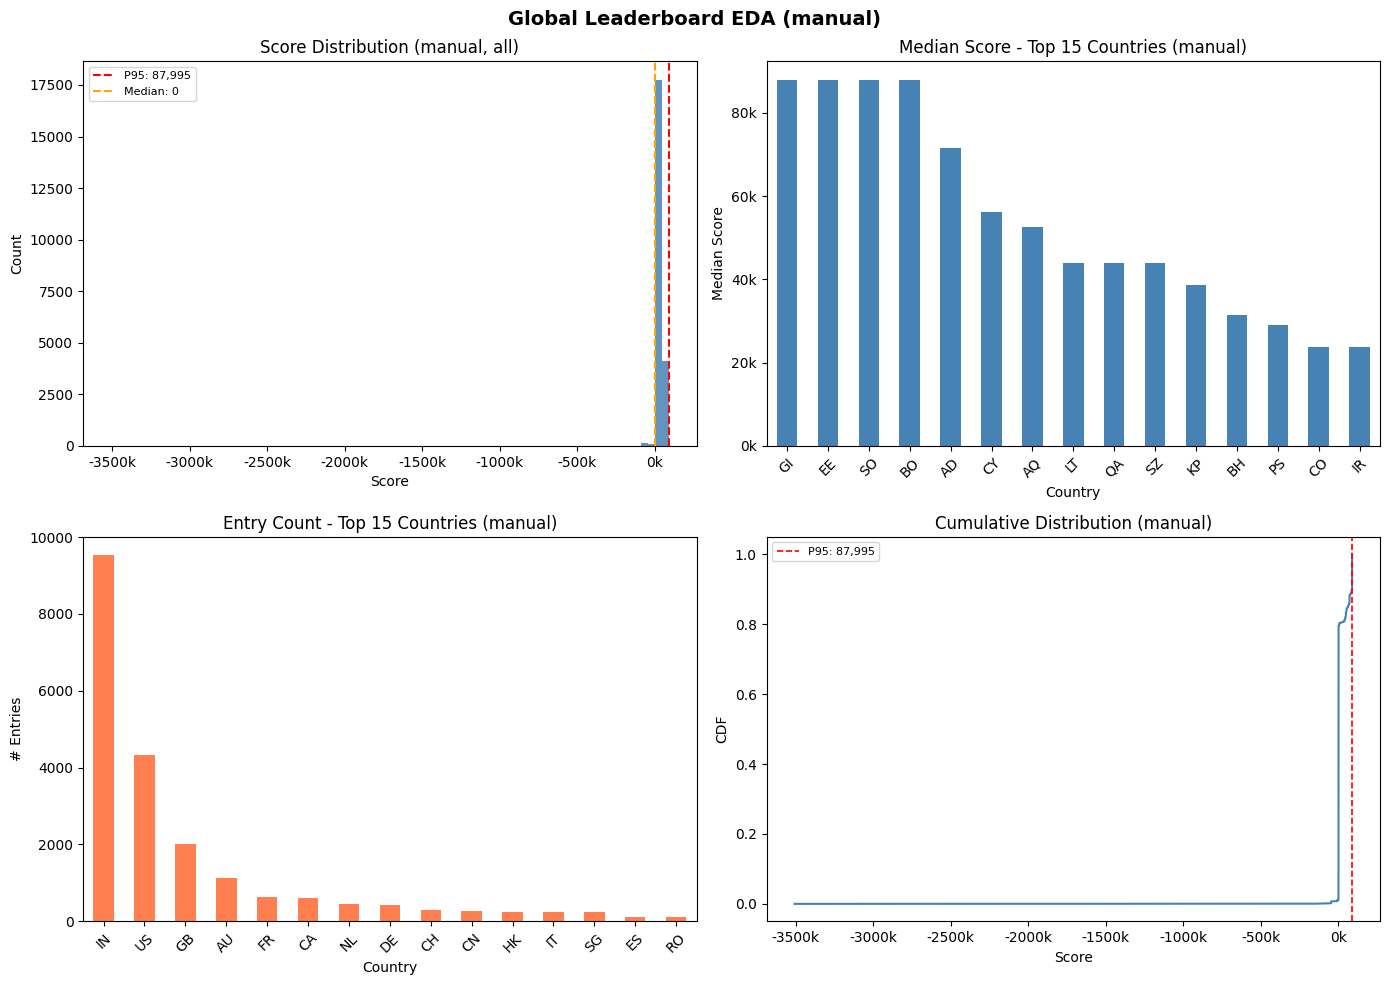

In [25]:

# --- MANUAL: Global EDA ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Global Leaderboard EDA (manual)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(dm['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(mp95, color='red', linestyle='--', linewidth=1.5, label=f'P95: {mp95:,.0f}')
ax.axvline(dm['score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {dm["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (manual, all)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

mtop_countries = dm.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[0, 1]
mtop_countries.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Countries (manual)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

mtop_count = dm['country_code'].value_counts().head(15)
ax = axes[1, 0]
mtop_count.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('# Entries'); ax.set_title('Entry Count - Top 15 Countries (manual)')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
ms_sorted = np.sort(dm['score'])
ms_cdf = np.arange(1, len(ms_sorted)+1) / len(ms_sorted)
ax.plot(ms_sorted, ms_cdf, color='steelblue', linewidth=1.5)
ax.axvline(mp95, color='red', linestyle='--', linewidth=1.2, label=f'P95: {mp95:,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Distribution (manual)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('manual_global_eda.png', dpi=130, bbox_inches='tight')
plt.show()


In [26]:

# --- MANUAL: India stats ---
dm_in = dm[dm['country_code'] == 'IN'].copy()
print(f"India entries: {len(dm_in)}")
print(f"India rank range: {dm_in['position'].min()} - {dm_in['position'].max()}")
print()
mp95_in = dm_in['score'].quantile(0.95)
mp99_in = dm_in['score'].quantile(0.99)
print(dm_in['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (IN): {mp95_in:,.2f}")
print(f"99th percentile (IN): {mp99_in:,.2f}")
print(f"Top India score: {dm_in['score'].max():,.2f}  (rank #{dm_in.loc[dm_in['score'].idxmax(),'position']})")


India entries: 9531
India rank range: 1 - 312

count    9.531000e+03
mean     7.449920e+03
std      5.222018e+04
min     -3.507500e+06
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      4.770000e+04
95%      8.100000e+04
99%      8.799510e+04
max      8.799510e+04
Name: score, dtype: float64

95th percentile (IN): 81,000.00
99th percentile (IN): 87,995.10
Top India score: 87,995.10  (rank #1)


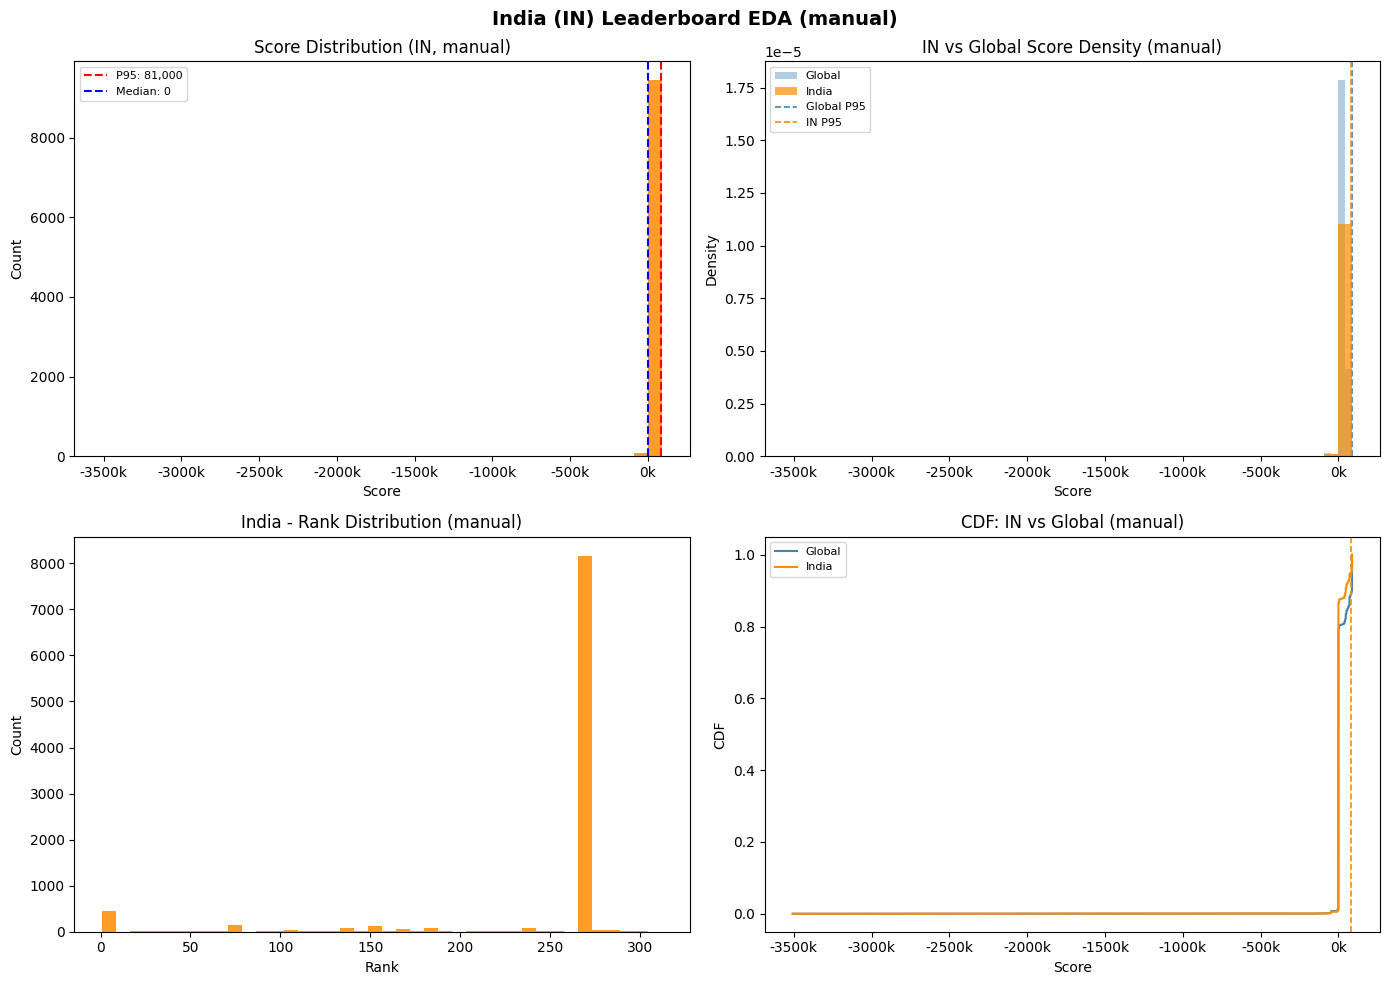

In [27]:

# --- MANUAL: India plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('India (IN) Leaderboard EDA (manual)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(dm_in['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.axvline(mp95_in, color='red', linestyle='--', linewidth=1.5, label=f'P95: {mp95_in:,.0f}')
ax.axvline(dm_in['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {dm_in["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (IN, manual)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(dm['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(dm_in['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.7, density=True, label='India')
ax.axvline(mp95, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(mp95_in, color='darkorange', linestyle='--', linewidth=1.2, label='IN P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('IN vs Global Score Density (manual)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(dm_in['position'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.set_xlabel('Rank'); ax.set_ylabel('Count'); ax.set_title('India - Rank Distribution (manual)')

ax = axes[1, 1]
ms_global = np.sort(dm['score'])
ms_cdf_g = np.arange(1, len(ms_global)+1) / len(ms_global)
ms_in = np.sort(dm_in['score'])
ms_cdf_in = np.arange(1, len(ms_in)+1) / len(ms_in)
ax.plot(ms_global, ms_cdf_g, color='steelblue', linewidth=1.5, label='Global')
ax.plot(ms_in, ms_cdf_in, color='darkorange', linewidth=1.5, label='India')
ax.axvline(mp95_in, color='darkorange', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: IN vs Global (manual)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('manual_india_eda.png', dpi=130, bbox_inches='tight')
plt.show()


In [28]:

# --- MANUAL: Filter score > 0 ---
dm_pos = dm[dm['score'] > 0].copy()
dm_in_pos = dm_pos[dm_pos['country_code'] == 'IN'].copy()

print(f"Global: {len(dm)} → {len(dm_pos)} (dropped {len(dm)-len(dm_pos)} zero/negative)")
print(f"India:  {len(dm_in)} → {len(dm_in_pos)} (dropped {len(dm_in)-len(dm_in_pos)})")


Global: 22130 → 4537 (dropped 17593 zero/negative)
India:  9531 → 1282 (dropped 8249)


In [29]:

# --- MANUAL: Global stats (score > 0) ---
print(f"Total entries: {len(dm_pos)}")
print(f"Countries: {dm_pos['country_code'].nunique()}")
print()
print(dm_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
mp95_pos = dm_pos['score'].quantile(0.95)
mp99_pos = dm_pos['score'].quantile(0.99)
print(f"95th percentile: {mp95_pos:,.2f}")
print(f"99th percentile: {mp99_pos:,.2f}")
print(f"Top score: {dm_pos['score'].max():,.2f}")
print(f"Bottom score: {dm_pos['score'].min():,.2f}")


Total entries: 4537
Countries: 83

count     4537.000000
mean     71420.585166
std      22489.488826
min          2.000000
5%       20700.000000
25%      56300.000000
50%      85995.200000
75%      87995.100000
90%      87995.100000
95%      87995.100000
99%      87995.100000
max      87995.100000
Name: score, dtype: float64

95th percentile: 87,995.10
99th percentile: 87,995.10
Top score: 87,995.10
Bottom score: 2.00


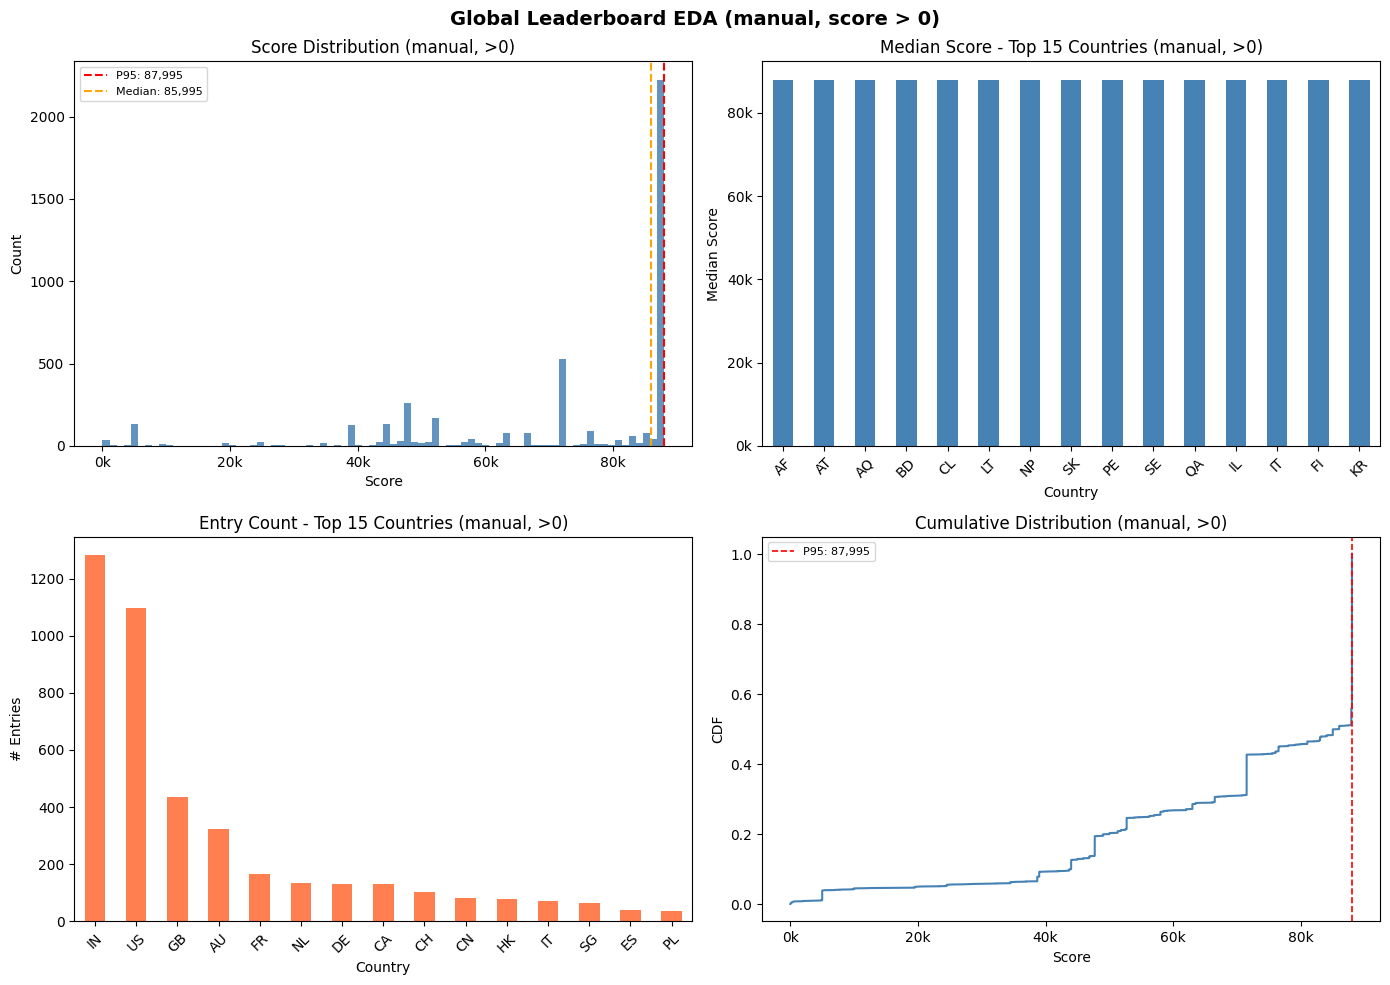

In [30]:

# --- MANUAL: Global EDA (score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Global Leaderboard EDA (manual, score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(dm_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(mp95_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {mp95_pos:,.0f}')
ax.axvline(dm_pos['score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {dm_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (manual, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

mtop_pos = dm_pos.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[0, 1]
mtop_pos.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Countries (manual, >0)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

mtop_count_pos = dm_pos['country_code'].value_counts().head(15)
ax = axes[1, 0]
mtop_count_pos.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('# Entries'); ax.set_title('Entry Count - Top 15 Countries (manual, >0)')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
ms_pos_s = np.sort(dm_pos['score'])
ms_pos_cdf = np.arange(1, len(ms_pos_s)+1) / len(ms_pos_s)
ax.plot(ms_pos_s, ms_pos_cdf, color='steelblue', linewidth=1.5)
ax.axvline(mp95_pos, color='red', linestyle='--', linewidth=1.2, label=f'P95: {mp95_pos:,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Distribution (manual, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('manual_global_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()


In [31]:

# --- MANUAL: India stats (score > 0) ---
print(f"India entries: {len(dm_in_pos)}")
print(f"India rank range: {dm_in_pos['position'].min()} - {dm_in_pos['position'].max()}")
print()
mp95_in_pos = dm_in_pos['score'].quantile(0.95)
mp99_in_pos = dm_in_pos['score'].quantile(0.99)
print(dm_in_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (IN, >0): {mp95_in_pos:,.2f}")
print(f"99th percentile (IN, >0): {mp99_in_pos:,.2f}")
print(f"Top India score: {dm_in_pos['score'].max():,.2f}  (rank #{dm_in_pos.loc[dm_in_pos['score'].idxmax(),'position']})")


India entries: 1282
India rank range: 1 - 270

count     1282.000000
mean     63156.781903
std      25361.520897
min          2.000000
5%        5000.000000
25%      47700.000000
50%      71500.000000
75%      87995.100000
90%      87995.100000
95%      87995.100000
99%      87995.100000
max      87995.100000
Name: score, dtype: float64

95th percentile (IN, >0): 87,995.10
99th percentile (IN, >0): 87,995.10
Top India score: 87,995.10  (rank #1)


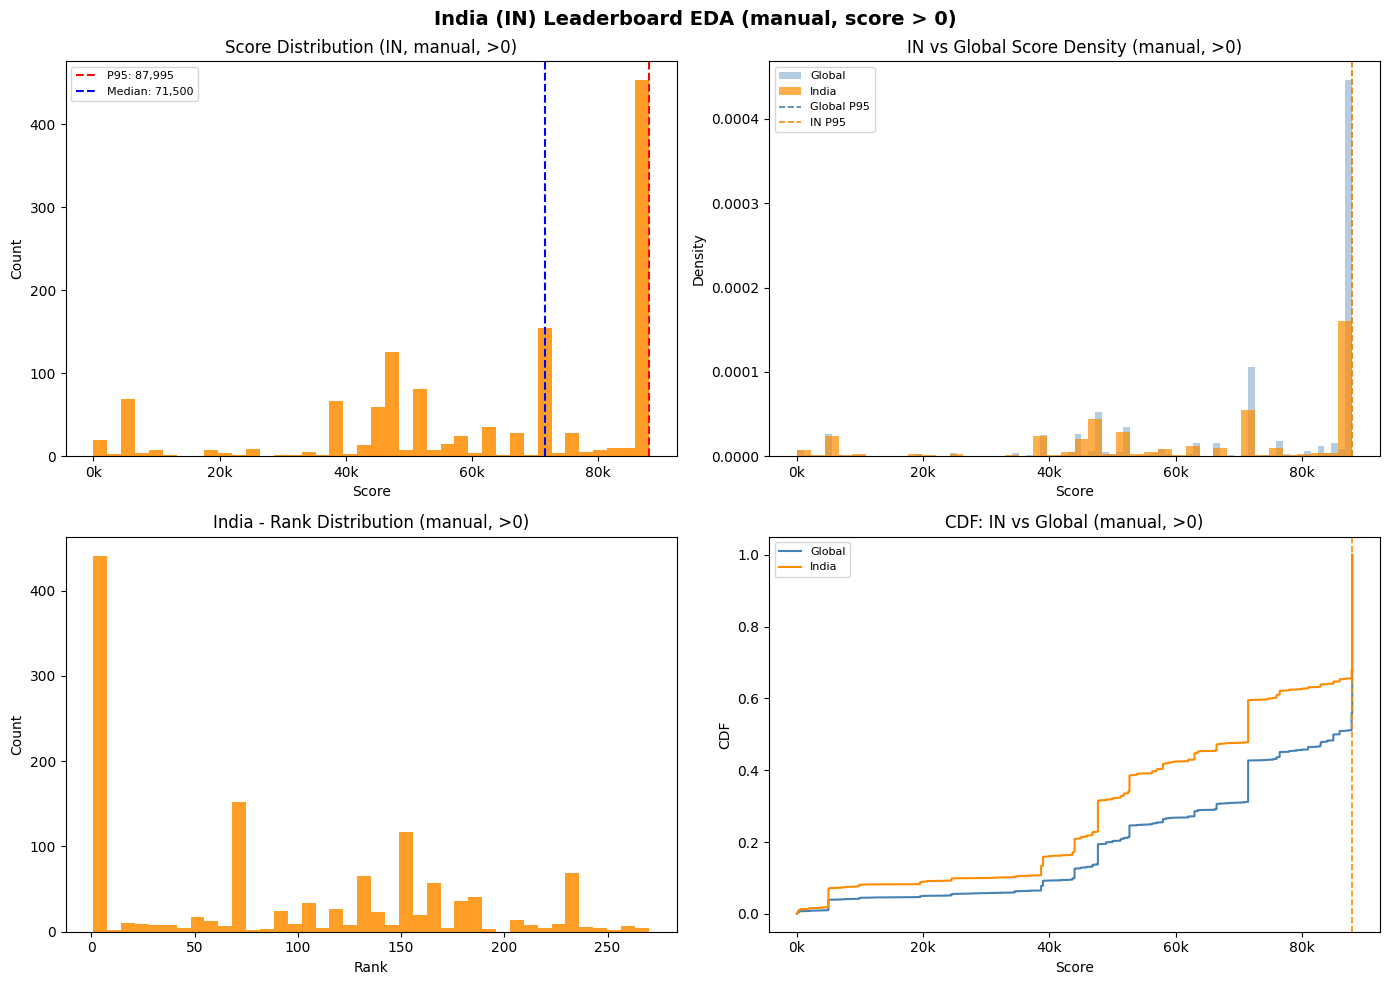

In [32]:

# --- MANUAL: India plots (score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('India (IN) Leaderboard EDA (manual, score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(dm_in_pos['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.axvline(mp95_in_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {mp95_in_pos:,.0f}')
ax.axvline(dm_in_pos['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {dm_in_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (IN, manual, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(dm_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(dm_in_pos['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.7, density=True, label='India')
ax.axvline(mp95_pos, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(mp95_in_pos, color='darkorange', linestyle='--', linewidth=1.2, label='IN P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('IN vs Global Score Density (manual, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(dm_in_pos['position'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.set_xlabel('Rank'); ax.set_ylabel('Count'); ax.set_title('India - Rank Distribution (manual, >0)')

ax = axes[1, 1]
ms_g2 = np.sort(dm_pos['score'])
ms_cdf_g2 = np.arange(1, len(ms_g2)+1) / len(ms_g2)
ms_in2 = np.sort(dm_in_pos['score'])
ms_cdf_in2 = np.arange(1, len(ms_in2)+1) / len(ms_in2)
ax.plot(ms_g2, ms_cdf_g2, color='steelblue', linewidth=1.5, label='Global')
ax.plot(ms_in2, ms_cdf_in2, color='darkorange', linewidth=1.5, label='India')
ax.axvline(mp95_in_pos, color='darkorange', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: IN vs Global (manual, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('manual_india_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()


---
## leaderboard_data_algo.csv — Full Analysis

In [33]:

# Load algo CSV
da = pd.read_csv('leaderboard_data_algo.csv', header=None,
                 names=['position','delta_position','uid','name','country_code','score'])
da.head()


,position,delta_position,uid,name,country_code,score
0,1,NaN,0aefbe81-3fab-49fa-af59-d86bdb34c5e1,yuh,AU,125850.17
1,2,NaN,97cb0d22-3873-4057-a856-28edf35c3387,Negative Eevee,NL,123244.41
2,3,NaN,60044fb4-0584-4d19-ba15-6f43d8e6f36a,Vibing,AU,121845.88
3,4,NaN,b2342095-b087-4597-9da1-564208152129,Seven Deuce Capital,US,120286.13
4,5,NaN,98265c6c-2e7e-414c-b8e3-806564f475f3,DU Trading,GB,120210.81


In [34]:

# --- ALGO: Basic stats ---
print(f"Total entries: {len(da)}")
print(f"Countries: {da['country_code'].nunique()}")
print()
print(da['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
ap95 = da['score'].quantile(0.95)
ap99 = da['score'].quantile(0.99)
print(f"95th percentile: {ap95:,.2f}")
print(f"99th percentile: {ap99:,.2f}")
print(f"Top score: {da['score'].max():,.2f}")
print(f"Bottom score: {da['score'].min():,.2f}")


Total entries: 22130
Countries: 132

count    2.213000e+04
mean     1.339664e+04
std      3.042837e+05
min     -4.042096e+07
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      9.373692e+04
95%      9.778878e+04
99%      1.025681e+05
max      1.258502e+05
Name: score, dtype: float64

95th percentile: 97,788.78
99th percentile: 102,568.07
Top score: 125,850.17
Bottom score: -40,420,962.55


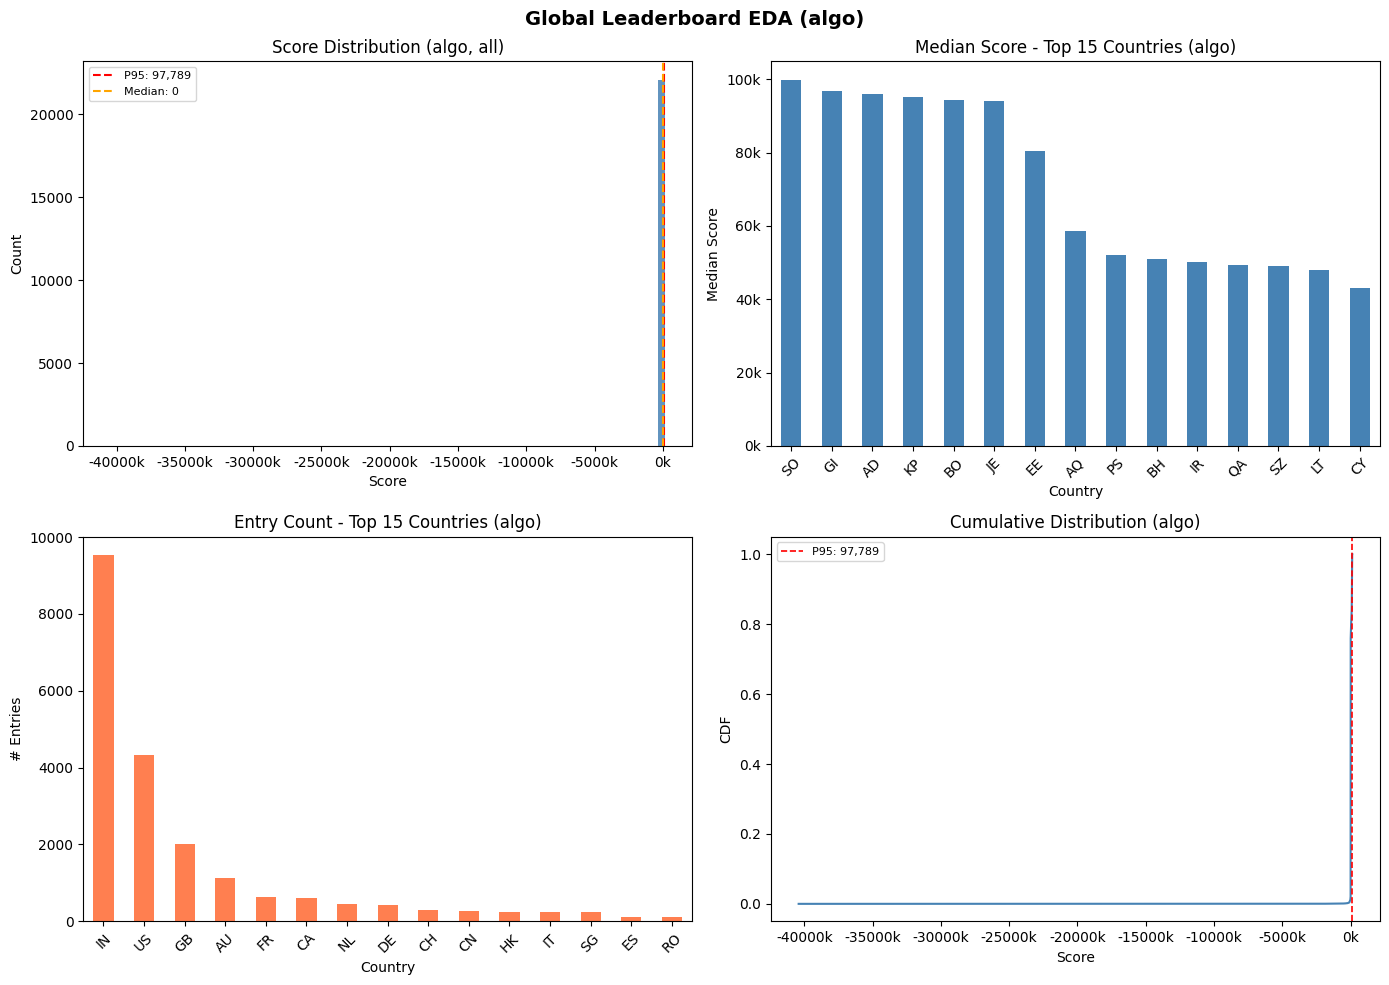

In [35]:

# --- ALGO: Global EDA ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Global Leaderboard EDA (algo)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(da['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(ap95, color='red', linestyle='--', linewidth=1.5, label=f'P95: {ap95:,.0f}')
ax.axvline(da['score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {da["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (algo, all)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

atop_countries = da.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[0, 1]
atop_countries.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Countries (algo)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

atop_count = da['country_code'].value_counts().head(15)
ax = axes[1, 0]
atop_count.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('# Entries'); ax.set_title('Entry Count - Top 15 Countries (algo)')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
as_sorted = np.sort(da['score'])
as_cdf = np.arange(1, len(as_sorted)+1) / len(as_sorted)
ax.plot(as_sorted, as_cdf, color='steelblue', linewidth=1.5)
ax.axvline(ap95, color='red', linestyle='--', linewidth=1.2, label=f'P95: {ap95:,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Distribution (algo)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('algo_global_eda.png', dpi=130, bbox_inches='tight')
plt.show()


In [36]:

# --- ALGO: India stats ---
da_in = da[da['country_code'] == 'IN'].copy()
print(f"India entries: {len(da_in)}")
print(f"India rank range: {da_in['position'].min()} - {da_in['position'].max()}")
print()
ap95_in = da_in['score'].quantile(0.95)
ap99_in = da_in['score'].quantile(0.99)
print(da_in['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (IN): {ap95_in:,.2f}")
print(f"99th percentile (IN): {ap99_in:,.2f}")
print(f"Top India score: {da_in['score'].max():,.2f}  (rank #{da_in.loc[da_in['score'].idxmax(),'position']})")


India entries: 9531
India rank range: 23 - 22129

count    9.531000e+03
mean     6.380613e+03
std      1.928686e+05
min     -1.793718e+07
5%       0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      6.403198e+04
95%      9.366375e+04
99%      9.954422e+04
max      1.166839e+05
Name: score, dtype: float64

95th percentile (IN): 93,663.75
99th percentile (IN): 99,544.22
Top India score: 116,683.94  (rank #23)


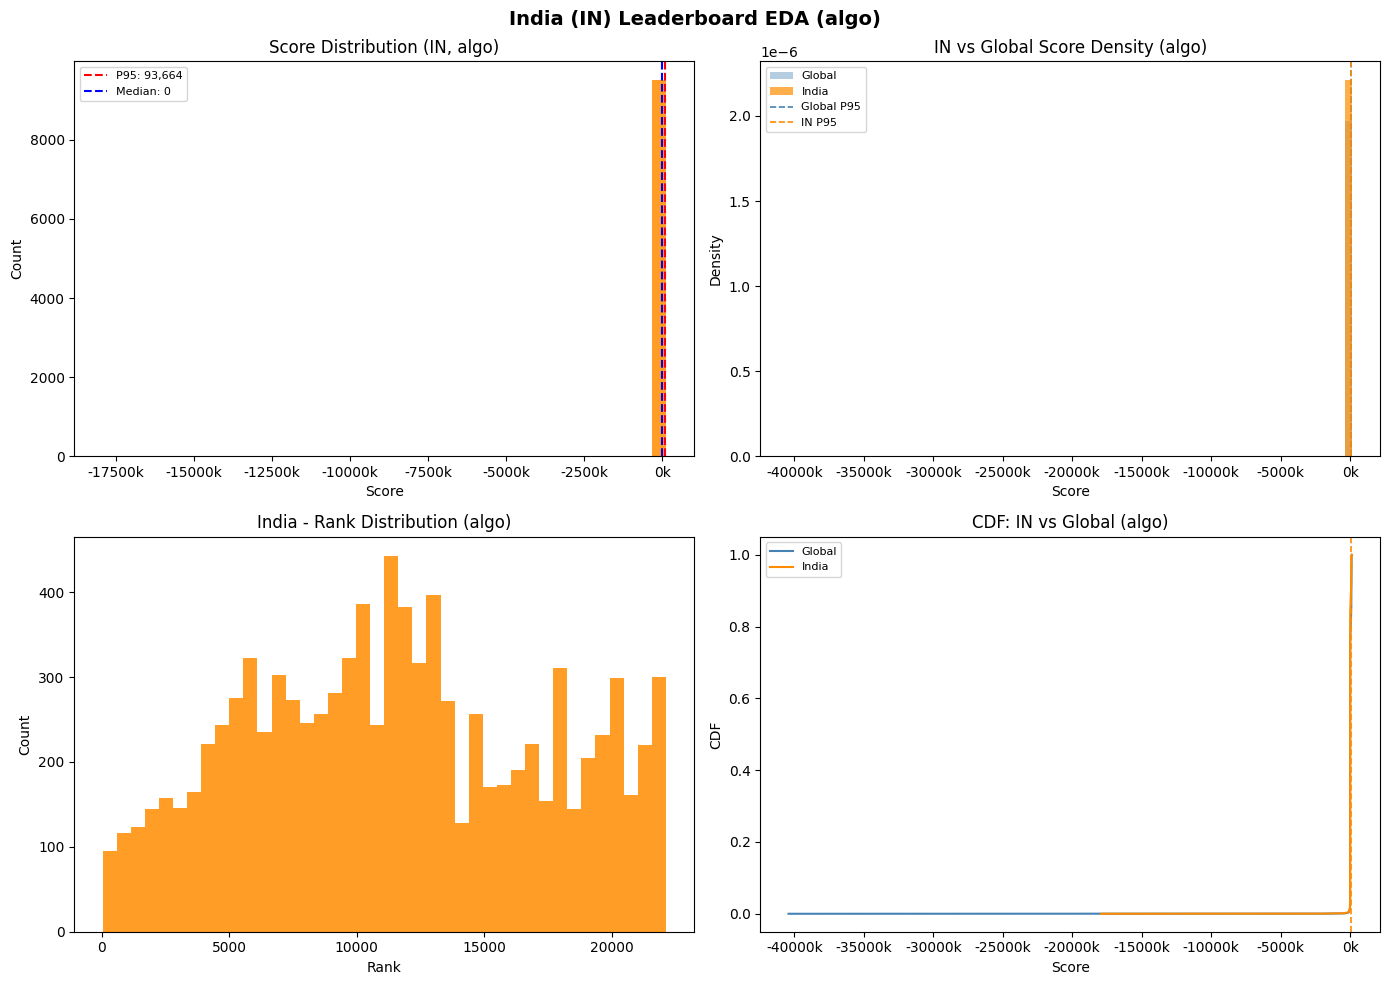

In [37]:

# --- ALGO: India plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('India (IN) Leaderboard EDA (algo)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(da_in['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.axvline(ap95_in, color='red', linestyle='--', linewidth=1.5, label=f'P95: {ap95_in:,.0f}')
ax.axvline(da_in['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {da_in["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (IN, algo)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(da['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(da_in['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.7, density=True, label='India')
ax.axvline(ap95, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(ap95_in, color='darkorange', linestyle='--', linewidth=1.2, label='IN P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('IN vs Global Score Density (algo)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(da_in['position'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.set_xlabel('Rank'); ax.set_ylabel('Count'); ax.set_title('India - Rank Distribution (algo)')

ax = axes[1, 1]
ag_s = np.sort(da['score'])
ag_cdf = np.arange(1, len(ag_s)+1) / len(ag_s)
ai_s = np.sort(da_in['score'])
ai_cdf = np.arange(1, len(ai_s)+1) / len(ai_s)
ax.plot(ag_s, ag_cdf, color='steelblue', linewidth=1.5, label='Global')
ax.plot(ai_s, ai_cdf, color='darkorange', linewidth=1.5, label='India')
ax.axvline(ap95_in, color='darkorange', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: IN vs Global (algo)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('algo_india_eda.png', dpi=130, bbox_inches='tight')
plt.show()


In [38]:

# --- ALGO: Filter score > 0 ---
da_pos = da[da['score'] > 0].copy()
da_in_pos = da_pos[da_pos['country_code'] == 'IN'].copy()

print(f"Global: {len(da)} → {len(da_pos)} (dropped {len(da)-len(da_pos)} zero/negative)")
print(f"India:  {len(da_in)} → {len(da_in_pos)} (dropped {len(da_in)-len(da_in_pos)})")


Global: 22130 → 5499 (dropped 16631 zero/negative)
India:  9531 → 1660 (dropped 7871)


In [39]:

# --- ALGO: Global stats (score > 0) ---
print(f"Total entries: {len(da_pos)}")
print(f"Countries: {da_pos['country_code'].nunique()}")
print()
print(da_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
ap95_pos = da_pos['score'].quantile(0.95)
ap99_pos = da_pos['score'].quantile(0.99)
print(f"95th percentile: {ap95_pos:,.2f}")
print(f"99th percentile: {ap99_pos:,.2f}")
print(f"Top score: {da_pos['score'].max():,.2f}")
print(f"Bottom score: {da_pos['score'].min():,.2f}")


Total entries: 5499
Countries: 86

count      5499.000000
mean      74414.025830
std       30794.680071
min          56.000000
5%        11758.916000
25%       55121.510000
50%       89935.440000
75%       96629.565000
90%       99697.824000
95%      101901.245000
99%      110520.610600
max      125850.170000
Name: score, dtype: float64

95th percentile: 101,901.24
99th percentile: 110,520.61
Top score: 125,850.17
Bottom score: 56.00


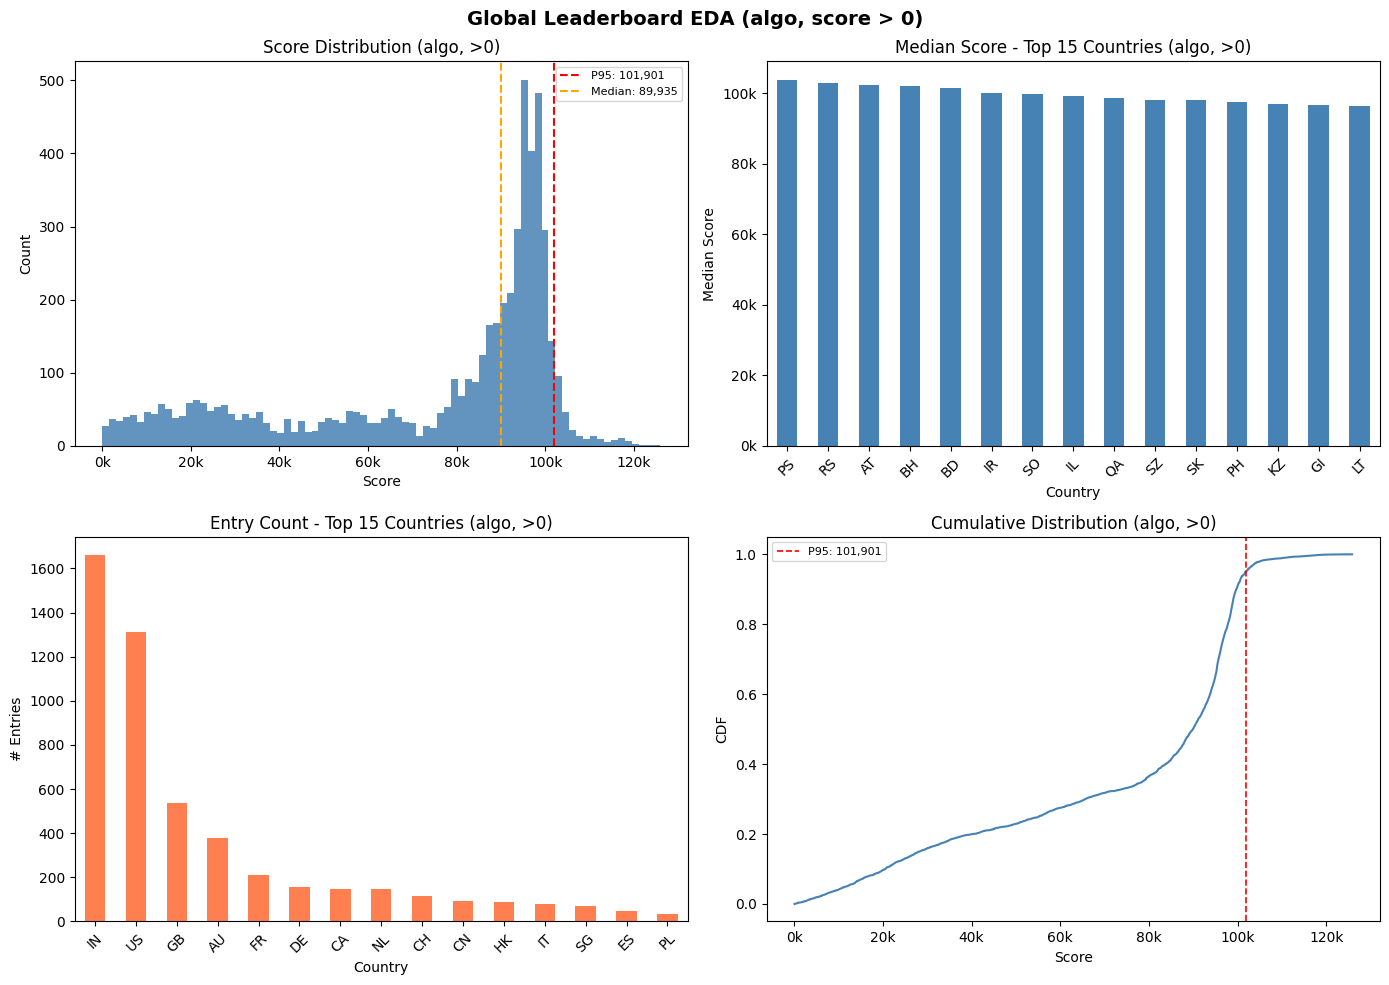

In [40]:

# --- ALGO: Global EDA (score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Global Leaderboard EDA (algo, score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(da_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.axvline(ap95_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {ap95_pos:,.0f}')
ax.axvline(da_pos['score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {da_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (algo, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

atop_pos = da_pos.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[0, 1]
atop_pos.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Countries (algo, >0)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

atop_cnt_pos = da_pos['country_code'].value_counts().head(15)
ax = axes[1, 0]
atop_cnt_pos.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('# Entries'); ax.set_title('Entry Count - Top 15 Countries (algo, >0)')
ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
ap_s = np.sort(da_pos['score'])
ap_cdf = np.arange(1, len(ap_s)+1) / len(ap_s)
ax.plot(ap_s, ap_cdf, color='steelblue', linewidth=1.5)
ax.axvline(ap95_pos, color='red', linestyle='--', linewidth=1.2, label=f'P95: {ap95_pos:,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('Cumulative Distribution (algo, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('algo_global_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()


In [41]:

# --- ALGO: India stats (score > 0) ---
print(f"India entries: {len(da_in_pos)}")
print(f"India rank range: {da_in_pos['position'].min()} - {da_in_pos['position'].max()}")
print()
ap95_in_pos = da_in_pos['score'].quantile(0.95)
ap99_in_pos = da_in_pos['score'].quantile(0.99)
print(da_in_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (IN, >0): {ap95_in_pos:,.2f}")
print(f"99th percentile (IN, >0): {ap99_in_pos:,.2f}")
print(f"Top India score: {da_in_pos['score'].max():,.2f}  (rank #{da_in_pos.loc[da_in_pos['score'].idxmax(),'position']})")


India entries: 1660
India rank range: 23 - 5499

count      1660.000000
mean      64486.892271
std       33663.698590
min          56.000000
5%         7344.830500
25%       30124.997500
50%       80135.190000
75%       94806.645000
90%       98481.428000
95%       99955.322000
99%      104289.020000
max      116683.940000
Name: score, dtype: float64

95th percentile (IN, >0): 99,955.32
99th percentile (IN, >0): 104,289.02
Top India score: 116,683.94  (rank #23)


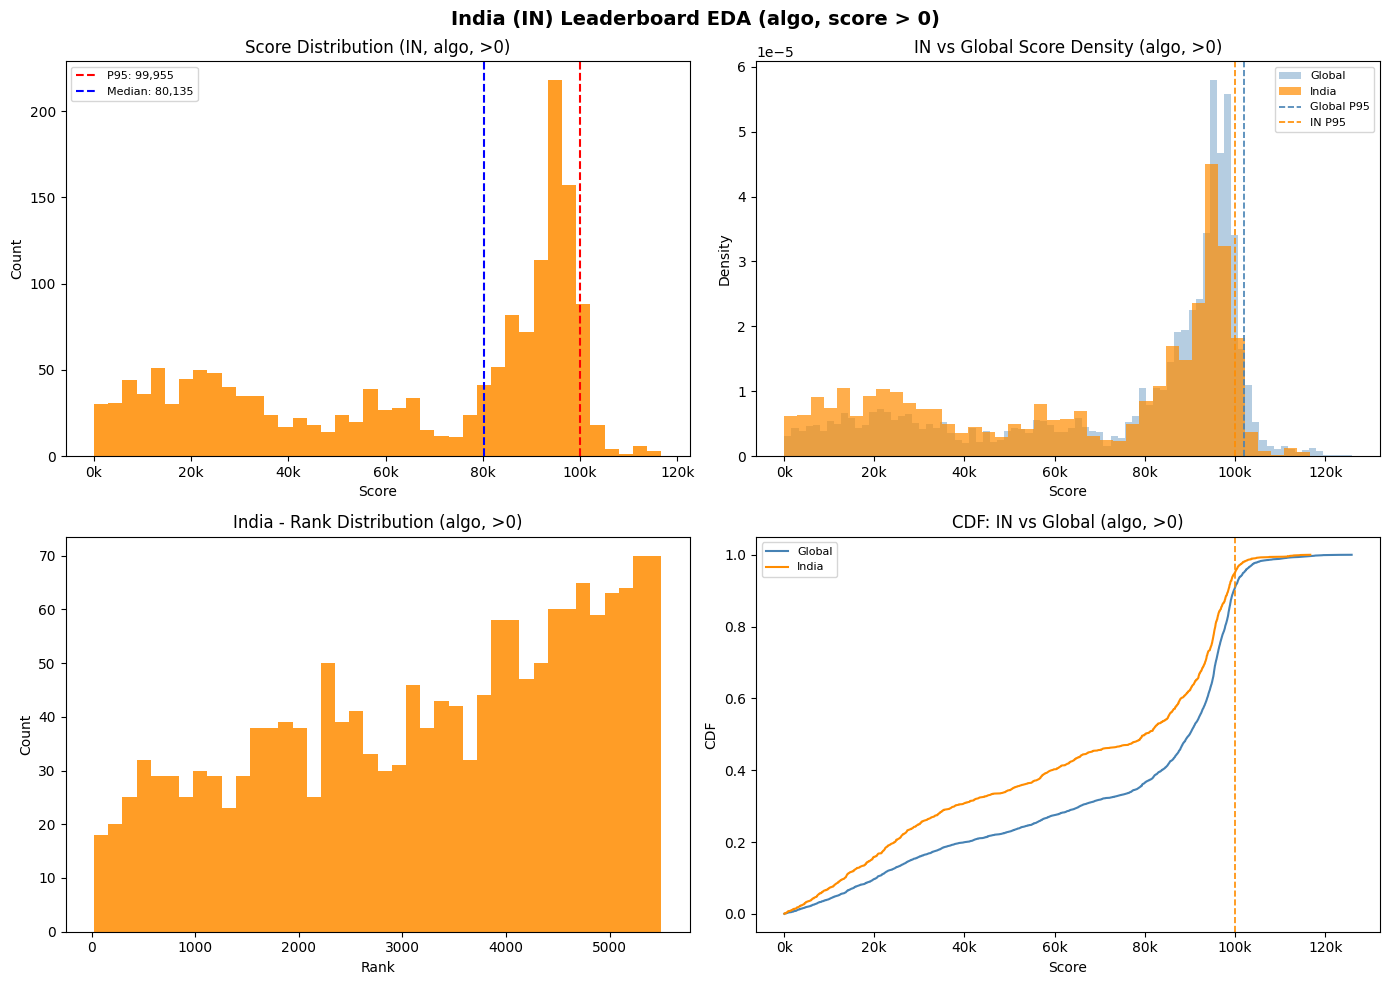

In [42]:

# --- ALGO: India plots (score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('India (IN) Leaderboard EDA (algo, score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(da_in_pos['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.axvline(ap95_in_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {ap95_in_pos:,.0f}')
ax.axvline(da_in_pos['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {da_in_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (IN, algo, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(da_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(da_in_pos['score'], bins=40, color='darkorange', edgecolor='none', alpha=0.7, density=True, label='India')
ax.axvline(ap95_pos, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(ap95_in_pos, color='darkorange', linestyle='--', linewidth=1.2, label='IN P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('IN vs Global Score Density (algo, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(da_in_pos['position'], bins=40, color='darkorange', edgecolor='none', alpha=0.85)
ax.set_xlabel('Rank'); ax.set_ylabel('Count'); ax.set_title('India - Rank Distribution (algo, >0)')

ax = axes[1, 1]
ag2 = np.sort(da_pos['score'])
ag2_cdf = np.arange(1, len(ag2)+1) / len(ag2)
ai2 = np.sort(da_in_pos['score'])
ai2_cdf = np.arange(1, len(ai2)+1) / len(ai2)
ax.plot(ag2, ag2_cdf, color='steelblue', linewidth=1.5, label='Global')
ax.plot(ai2, ai2_cdf, color='darkorange', linewidth=1.5, label='India')
ax.axvline(ap95_in_pos, color='darkorange', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: IN vs Global (algo, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('algo_india_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Asia Analysis (all three CSVs)

In [ ]:
# --- ASIA COUNTRY CODES & LEADERBOARD FILTER ---
ASIA_CODES = {
    # East Asia
    'CN', 'JP', 'KR', 'TW', 'HK', 'MN',
    # Southeast Asia
    'ID', 'MY', 'PH', 'SG', 'TH', 'VN', 'MM', 'KH', 'LA', 'BN', 'TL',
    # South Asia
    'IN', 'PK', 'BD', 'LK', 'NP', 'BT', 'MV', 'AF',
    # Central Asia
    'KZ', 'KG', 'TJ', 'TM', 'UZ',
    # Western Asia
    'AE', 'AM', 'AZ', 'BH', 'CY', 'GE', 'IQ', 'IR', 'IL', 'JO', 'KW', 'LB', 'OM', 'QA', 'SA', 'SY', 'TR', 'YE',
}

# Overall leaderboard — Asia
df_asia = df[df['country_code'].isin(ASIA_CODES)].copy()
df_asia_ranked = df_asia.sort_values('score', ascending=False).reset_index(drop=True)
df_asia_ranked.index += 1
df_asia_ranked.index.name = 'asia_rank'
print(f"Asia entries (overall): {len(df_asia)}")
print(f"Asia countries present: {sorted(df_asia['country_code'].unique())}")
df_asia_ranked.head(20)

In [ ]:
# --- ASIA STATS (overall, all scores) ---
print(f"Asia entries: {len(df_asia)}")
print(f"Asia rank range (global): {df_asia['position'].min()} - {df_asia['position'].max()}")
print()
p95_asia = df_asia['score'].quantile(0.95)
p99_asia = df_asia['score'].quantile(0.99)
print(df_asia['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (Asia): {p95_asia:,.2f}")
print(f"99th percentile (Asia): {p99_asia:,.2f}")
print(f"Top Asia score: {df_asia['score'].max():,.2f}  (global rank #{df_asia.loc[df_asia['score'].idxmax(),'position']})")
print()
# Country breakdown
print(df_asia.groupby('country_code').agg(count=('score','count'), median_score=('score','median'), top_score=('score','max')).sort_values('count', ascending=False).to_string())

In [ ]:
# --- ASIA PLOTS (overall, all scores) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Asia Leaderboard EDA (overall)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(df_asia['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(p95_asia, color='red', linestyle='--', linewidth=1.5, label=f'P95: {p95_asia:,.0f}')
ax.axvline(df_asia['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {df_asia["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (Asia)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(df['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(df_asia['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.7, density=True, label='Asia')
ax.axvline(p95, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(p95_asia, color='mediumseagreen', linestyle='--', linewidth=1.2, label='Asia P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('Asia vs Global Score Density')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

top_asia_countries = df_asia.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[1, 0]
top_asia_countries.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Asia Countries')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 1]
sorted_global = np.sort(df['score'])
cdf_global = np.arange(1, len(sorted_global)+1) / len(sorted_global)
sorted_asia = np.sort(df_asia['score'])
cdf_asia = np.arange(1, len(sorted_asia)+1) / len(sorted_asia)
ax.plot(sorted_global, cdf_global, color='steelblue', linewidth=1.5, label='Global')
ax.plot(sorted_asia, cdf_asia, color='mediumseagreen', linewidth=1.5, label='Asia')
ax.axvline(p95_asia, color='mediumseagreen', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: Asia vs Global')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('leaderboard_asia_eda.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# --- ASIA: Filter score > 0 (overall) ---
df_asia_pos = df_pos[df_pos['country_code'].isin(ASIA_CODES)].copy()
print(f"Asia (overall): {len(df_asia)} → {len(df_asia_pos)} (dropped {len(df_asia)-len(df_asia_pos)} zero/negative)")

In [ ]:
# --- ASIA STATS (overall, score > 0) ---
print(f"Asia entries: {len(df_asia_pos)}")
print(f"Asia rank range (global): {df_asia_pos['position'].min()} - {df_asia_pos['position'].max()}")
print()
p95_asia_pos = df_asia_pos['score'].quantile(0.95)
p99_asia_pos = df_asia_pos['score'].quantile(0.99)
print(df_asia_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (Asia, >0): {p95_asia_pos:,.2f}")
print(f"99th percentile (Asia, >0): {p99_asia_pos:,.2f}")
print(f"Top Asia score: {df_asia_pos['score'].max():,.2f}  (global rank #{df_asia_pos.loc[df_asia_pos['score'].idxmax(),'position']})")
print()
print(df_asia_pos.groupby('country_code').agg(count=('score','count'), median_score=('score','median'), top_score=('score','max')).sort_values('count', ascending=False).to_string())

In [ ]:
# --- ASIA PLOTS (overall, score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Asia Leaderboard EDA (overall, score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(df_asia_pos['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(p95_asia_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {p95_asia_pos:,.0f}')
ax.axvline(df_asia_pos['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {df_asia_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (Asia, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(df_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(df_asia_pos['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.7, density=True, label='Asia')
ax.axvline(p95_pos, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(p95_asia_pos, color='mediumseagreen', linestyle='--', linewidth=1.2, label='Asia P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('Asia vs Global Score Density (>0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(df_asia_pos['position'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.set_xlabel('Global Rank'); ax.set_ylabel('Count'); ax.set_title('Asia - Global Rank Distribution (>0)')

ax = axes[1, 1]
sg_pos = np.sort(df_pos['score'])
scdf_pos = np.arange(1, len(sg_pos)+1) / len(sg_pos)
sa_pos = np.sort(df_asia_pos['score'])
scdf_asia_pos = np.arange(1, len(sa_pos)+1) / len(sa_pos)
ax.plot(sg_pos, scdf_pos, color='steelblue', linewidth=1.5, label='Global')
ax.plot(sa_pos, scdf_asia_pos, color='mediumseagreen', linewidth=1.5, label='Asia')
ax.axvline(p95_asia_pos, color='mediumseagreen', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: Asia vs Global (>0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('leaderboard_asia_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()

---
### Manual CSV — Asia Analysis

In [ ]:
# --- MANUAL: Asia leaderboard ---
dm_asia = dm[dm['country_code'].isin(ASIA_CODES)].copy()
dm_asia_ranked = dm_asia.sort_values('score', ascending=False).reset_index(drop=True)
dm_asia_ranked.index += 1
dm_asia_ranked.index.name = 'asia_rank'
print(f"Asia entries (manual): {len(dm_asia)}")
print(f"Asia countries present: {sorted(dm_asia['country_code'].unique())}")
dm_asia_ranked.head(20)

In [ ]:
# --- MANUAL: Asia stats (all scores) ---
print(f"Asia entries: {len(dm_asia)}")
print(f"Asia rank range: {dm_asia['position'].min()} - {dm_asia['position'].max()}")
print()
mp95_asia = dm_asia['score'].quantile(0.95)
mp99_asia = dm_asia['score'].quantile(0.99)
print(dm_asia['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (Asia): {mp95_asia:,.2f}")
print(f"99th percentile (Asia): {mp99_asia:,.2f}")
print(f"Top Asia score: {dm_asia['score'].max():,.2f}  (rank #{dm_asia.loc[dm_asia['score'].idxmax(),'position']})")
print()
print(dm_asia.groupby('country_code').agg(count=('score','count'), median_score=('score','median'), top_score=('score','max')).sort_values('count', ascending=False).to_string())

In [ ]:
# --- MANUAL: Asia plots (all scores) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Asia Leaderboard EDA (manual)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(dm_asia['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(mp95_asia, color='red', linestyle='--', linewidth=1.5, label=f'P95: {mp95_asia:,.0f}')
ax.axvline(dm_asia['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {dm_asia["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (Asia, manual)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(dm['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(dm_asia['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.7, density=True, label='Asia')
ax.axvline(mp95, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(mp95_asia, color='mediumseagreen', linestyle='--', linewidth=1.2, label='Asia P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('Asia vs Global Score Density (manual)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

mtop_asia = dm_asia.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[1, 0]
mtop_asia.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Asia Countries (manual)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 1]
mg_s = np.sort(dm['score'])
mg_cdf = np.arange(1, len(mg_s)+1) / len(mg_s)
ma_s = np.sort(dm_asia['score'])
ma_cdf = np.arange(1, len(ma_s)+1) / len(ma_s)
ax.plot(mg_s, mg_cdf, color='steelblue', linewidth=1.5, label='Global')
ax.plot(ma_s, ma_cdf, color='mediumseagreen', linewidth=1.5, label='Asia')
ax.axvline(mp95_asia, color='mediumseagreen', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: Asia vs Global (manual)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('manual_asia_eda.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# --- MANUAL: Asia filter score > 0 ---
dm_asia_pos = dm_pos[dm_pos['country_code'].isin(ASIA_CODES)].copy()
print(f"Asia (manual): {len(dm_asia)} → {len(dm_asia_pos)} (dropped {len(dm_asia)-len(dm_asia_pos)} zero/negative)")

In [ ]:
# --- MANUAL: Asia stats (score > 0) ---
print(f"Asia entries: {len(dm_asia_pos)}")
print(f"Asia rank range: {dm_asia_pos['position'].min()} - {dm_asia_pos['position'].max()}")
print()
mp95_asia_pos = dm_asia_pos['score'].quantile(0.95)
mp99_asia_pos = dm_asia_pos['score'].quantile(0.99)
print(dm_asia_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (Asia, >0): {mp95_asia_pos:,.2f}")
print(f"99th percentile (Asia, >0): {mp99_asia_pos:,.2f}")
print(f"Top Asia score: {dm_asia_pos['score'].max():,.2f}  (rank #{dm_asia_pos.loc[dm_asia_pos['score'].idxmax(),'position']})")
print()
print(dm_asia_pos.groupby('country_code').agg(count=('score','count'), median_score=('score','median'), top_score=('score','max')).sort_values('count', ascending=False).to_string())

In [ ]:
# --- MANUAL: Asia plots (score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Asia Leaderboard EDA (manual, score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(dm_asia_pos['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(mp95_asia_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {mp95_asia_pos:,.0f}')
ax.axvline(dm_asia_pos['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {dm_asia_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (Asia, manual, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(dm_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(dm_asia_pos['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.7, density=True, label='Asia')
ax.axvline(mp95_pos, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(mp95_asia_pos, color='mediumseagreen', linestyle='--', linewidth=1.2, label='Asia P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('Asia vs Global Score Density (manual, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(dm_asia_pos['position'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.set_xlabel('Rank'); ax.set_ylabel('Count'); ax.set_title('Asia - Rank Distribution (manual, >0)')

ax = axes[1, 1]
mg2 = np.sort(dm_pos['score'])
mg2_cdf = np.arange(1, len(mg2)+1) / len(mg2)
ma2 = np.sort(dm_asia_pos['score'])
ma2_cdf = np.arange(1, len(ma2)+1) / len(ma2)
ax.plot(mg2, mg2_cdf, color='steelblue', linewidth=1.5, label='Global')
ax.plot(ma2, ma2_cdf, color='mediumseagreen', linewidth=1.5, label='Asia')
ax.axvline(mp95_asia_pos, color='mediumseagreen', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: Asia vs Global (manual, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('manual_asia_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()

---
### Algo CSV — Asia Analysis

In [ ]:
# --- ALGO: Asia leaderboard ---
da_asia = da[da['country_code'].isin(ASIA_CODES)].copy()
da_asia_ranked = da_asia.sort_values('score', ascending=False).reset_index(drop=True)
da_asia_ranked.index += 1
da_asia_ranked.index.name = 'asia_rank'
print(f"Asia entries (algo): {len(da_asia)}")
print(f"Asia countries present: {sorted(da_asia['country_code'].unique())}")
da_asia_ranked.head(20)

In [ ]:
# --- ALGO: Asia stats (all scores) ---
print(f"Asia entries: {len(da_asia)}")
print(f"Asia rank range (global): {da_asia['position'].min()} - {da_asia['position'].max()}")
print()
ap95_asia = da_asia['score'].quantile(0.95)
ap99_asia = da_asia['score'].quantile(0.99)
print(da_asia['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (Asia): {ap95_asia:,.2f}")
print(f"99th percentile (Asia): {ap99_asia:,.2f}")
print(f"Top Asia score: {da_asia['score'].max():,.2f}  (global rank #{da_asia.loc[da_asia['score'].idxmax(),'position']})")
print()
print(da_asia.groupby('country_code').agg(count=('score','count'), median_score=('score','median'), top_score=('score','max')).sort_values('count', ascending=False).to_string())

In [ ]:
# --- ALGO: Asia plots (all scores) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Asia Leaderboard EDA (algo)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(da_asia['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(ap95_asia, color='red', linestyle='--', linewidth=1.5, label=f'P95: {ap95_asia:,.0f}')
ax.axvline(da_asia['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {da_asia["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (Asia, algo)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(da['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(da_asia['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.7, density=True, label='Asia')
ax.axvline(ap95, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(ap95_asia, color='mediumseagreen', linestyle='--', linewidth=1.2, label='Asia P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('Asia vs Global Score Density (algo)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

atop_asia = da_asia.groupby('country_code')['score'].median().sort_values(ascending=False).head(15)
ax = axes[1, 0]
atop_asia.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='none')
ax.set_xlabel('Country'); ax.set_ylabel('Median Score'); ax.set_title('Median Score - Top 15 Asia Countries (algo)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 1]
ag_s2 = np.sort(da['score'])
ag_cdf2 = np.arange(1, len(ag_s2)+1) / len(ag_s2)
aa_s = np.sort(da_asia['score'])
aa_cdf = np.arange(1, len(aa_s)+1) / len(aa_s)
ax.plot(ag_s2, ag_cdf2, color='steelblue', linewidth=1.5, label='Global')
ax.plot(aa_s, aa_cdf, color='mediumseagreen', linewidth=1.5, label='Asia')
ax.axvline(ap95_asia, color='mediumseagreen', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: Asia vs Global (algo)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('algo_asia_eda.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# --- ALGO: Asia filter score > 0 ---
da_asia_pos = da_pos[da_pos['country_code'].isin(ASIA_CODES)].copy()
print(f"Asia (algo): {len(da_asia)} → {len(da_asia_pos)} (dropped {len(da_asia)-len(da_asia_pos)} zero/negative)")

In [ ]:
# --- ALGO: Asia stats (score > 0) ---
print(f"Asia entries: {len(da_asia_pos)}")
print(f"Asia rank range (global): {da_asia_pos['position'].min()} - {da_asia_pos['position'].max()}")
print()
ap95_asia_pos = da_asia_pos['score'].quantile(0.95)
ap99_asia_pos = da_asia_pos['score'].quantile(0.99)
print(da_asia_pos['score'].describe(percentiles=[.05,.25,.5,.75,.90,.95,.99]))
print()
print(f"95th percentile (Asia, >0): {ap95_asia_pos:,.2f}")
print(f"99th percentile (Asia, >0): {ap99_asia_pos:,.2f}")
print(f"Top Asia score: {da_asia_pos['score'].max():,.2f}  (global rank #{da_asia_pos.loc[da_asia_pos['score'].idxmax(),'position']})")
print()
print(da_asia_pos.groupby('country_code').agg(count=('score','count'), median_score=('score','median'), top_score=('score','max')).sort_values('count', ascending=False).to_string())

In [ ]:
# --- ALGO: Asia plots (score > 0) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Asia Leaderboard EDA (algo, score > 0)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(da_asia_pos['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.axvline(ap95_asia_pos, color='red', linestyle='--', linewidth=1.5, label=f'P95: {ap95_asia_pos:,.0f}')
ax.axvline(da_asia_pos['score'].median(), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {da_asia_pos["score"].median():,.0f}')
ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_title('Score Distribution (Asia, algo, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[0, 1]
ax.hist(da_pos['score'], bins=80, color='steelblue', edgecolor='none', alpha=0.4, density=True, label='Global')
ax.hist(da_asia_pos['score'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.7, density=True, label='Asia')
ax.axvline(ap95_pos, color='steelblue', linestyle='--', linewidth=1.2, label='Global P95')
ax.axvline(ap95_asia_pos, color='mediumseagreen', linestyle='--', linewidth=1.2, label='Asia P95')
ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.set_title('Asia vs Global Score Density (algo, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

ax = axes[1, 0]
ax.hist(da_asia_pos['position'], bins=40, color='mediumseagreen', edgecolor='none', alpha=0.85)
ax.set_xlabel('Global Rank'); ax.set_ylabel('Count'); ax.set_title('Asia - Rank Distribution (algo, >0)')

ax = axes[1, 1]
ag3 = np.sort(da_pos['score'])
ag3_cdf = np.arange(1, len(ag3)+1) / len(ag3)
aa3 = np.sort(da_asia_pos['score'])
aa3_cdf = np.arange(1, len(aa3)+1) / len(aa3)
ax.plot(ag3, ag3_cdf, color='steelblue', linewidth=1.5, label='Global')
ax.plot(aa3, aa3_cdf, color='mediumseagreen', linewidth=1.5, label='Asia')
ax.axvline(ap95_asia_pos, color='mediumseagreen', linestyle='--', linewidth=1.2)
ax.set_xlabel('Score'); ax.set_ylabel('CDF'); ax.set_title('CDF: Asia vs Global (algo, >0)')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('algo_asia_pos_eda.png', dpi=130, bbox_inches='tight')
plt.show()